# Chapter 15 — Interest-Rate Exposure and XVA

## EE, EPE, PFE, Collateral, CVA, DVA, and FVA

This chapter reuses the Gaussian LIBOR Market Model from Chapter 13.

The objective is to transform simulated future forward curves into future swap values, exposure profiles, collateralized exposure, and simplified XVA measures.

```text
Chapter 13 Gaussian LMM paths
            ↓
future forward curves
            ↓
future IRS mark-to-market values
            ↓
netting-set portfolio values
            ↓
EE, ENE, EPE, and PFE
            ↓
collateralized exposure
            ↓
CVA, DVA, and FVA
```

## 1. Learning Objectives

After completing this notebook, the reader should understand:

- how interest-rate paths become future trade values;
- why counterparty exposure is a distribution rather than one number;
- how close-out netting changes exposure;
- the meanings of EE, ENE, EPE, and PFE;
- how collateral thresholds, MTA, and lag affect exposure;
- how simplified CVA, DVA, and FVA are calculated.

## 2. Project Structure and Relative Paths

```text
Rates-Pricing-Quant-Library/
├── 13_gaussain_libor_market_model_lmm/
│   ├── python/
│   └── usd_zero_curve.csv
│
└── 15_interest_rate_exposure_and_xva/
    ├── notebooks/
    │   └── 15_interest_rate_exposure_and_xva.ipynb
    ├── python/
    │   ├── xva_trade.py
    │   ├── xva_exposure.py
    │   ├── xva_collateral.py
    │   ├── xva_metrics.py
    │   ├── xva_adjustments.py
    │   └── xva_plotting.py
    └── tests/
        └── test.py
```

Run the notebook with the working directory set to the Chapter 15 `notebooks` folder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHAPTER15_PYTHON = Path("../python")

CHAPTER13 = Path(
    "../../13_gaussain_libor_market_model_lmm"
)

CHAPTER13_PYTHON = (
    CHAPTER13
    /
    "python"
)

sys.path.insert(
    0,
    str(
        CHAPTER15_PYTHON
    )
)

sys.path.insert(
    1,
    str(
        CHAPTER13_PYTHON
    )
)

print(
    "Chapter 15 Python path:",
    CHAPTER15_PYTHON.resolve()
)

print(
    "Chapter 13 Python path:",
    CHAPTER13_PYTHON.resolve()
)

Chapter 15 Python path: C:\Users\HP16-af0022TU (D)\Desktop\Rates-Pricing-Quant-Library\15_Interest-Rate Counterparty Exposure and XVA\python
Chapter 13 Python path: C:\Users\HP16-af0022TU (D)\Desktop\Rates-Pricing-Quant-Library\13_gaussain_libor_market_model_lmm\python


## 3. Import Chapter 13 Gaussian LMM Components

Chapter 15 only requires:

```text
simulation.times
simulation.forward_paths[path, time, forward]
```

The exposure engine does not need to know the internal details of the Gaussian LMM after the paths have been generated.

In [2]:
from market_data import load_curve_data

from tenor_structure import TenorStructure

from correlation import (
    exponential_correlation_matrix,
    principal_component_loadings
)

from volatility import GaussianLMMVolatility

from gaussian_lmm import GaussianLMM

from simulation import simulate_gaussian_lmm

## 4. Import Chapter 15 Exposure and XVA Components

In [3]:
from xva_trade import (
    InterestRateSwap,
    NettingSet
)

from xva_exposure import (
    build_exposure_times,
    simulate_portfolio_values
)

from xva_collateral import (
    CSAParameters,
    simulate_collateral_paths,
    collateralized_portfolio_values
)

from xva_metrics import (
    calculate_exposure_metrics,
    compare_exposure_profiles
)

from xva_adjustments import (
    CreditCurve,
    calculate_xva
)

from xva_plotting import (
    plot_exposure_profile,
    plot_portfolio_value_distribution,
    plot_collateral_comparison,
    plot_mean_collateral_profile,
    plot_xva_components
)

## 5. Load the Initial Zero Curve

Discount factors are related to zero rates by:

$$
P(0,T)
=
\exp
\left[
-z(0,T)T
\right].
$$

The simple forward rate over the interval from \(T_i\) to \(T_{i+1}\) is:

$$
L_i(0)
=
\frac{1}{\delta_i}
\left[
\frac{P(0,T_i)}
{P(0,T_{i+1})}
-
1
\right].
$$

In [5]:
CURVE_FILE = (
    CHAPTER13
    /
    "data/usd_zero_curve.csv"
)

curve = load_curve_data(
    CURVE_FILE
)

print(
    "Curve file:",
    CURVE_FILE.resolve()
)

Curve file: C:\Users\HP16-af0022TU (D)\Desktop\Rates-Pricing-Quant-Library\13_gaussain_libor_market_model_lmm\data\usd_zero_curve.csv


## 6. Build the Tenor and Initial Forward Curve

A semiannual tenor is used from 0 to 10 years.

$$
0=T_0<T_1<\cdots<T_N.
$$

$$
\delta_i
=
T_{i+1}-T_i.
$$

Future swap revaluation is performed at tenor-aligned dates.

In [6]:
tenor = TenorStructure(
    start=0.0,
    end=10.0,
    payment_frequency=2
)

initial_forwards = tenor.initial_forward_rates(
    curve
)

initial_discount_factors = tenor.initial_discount_factors(
    curve
)

reset_times = np.asarray(
    tenor.times[:-1],
    dtype=float
)

pd.DataFrame(
    {
        "reset_time": reset_times,
        "initial_forward": initial_forwards
    }
).head(10)

,reset_time,initial_forward
0,0.0,0.021111
1,0.5,0.023133
2,1.0,0.025157
3,1.5,0.027183
4,2.0,0.026676
5,2.5,0.027690
6,3.0,0.028704
7,3.5,0.029719
8,4.0,0.030734
9,4.5,0.031749


## 7. Build the Gaussian LMM

The Chapter 13 model is:

$$
dL_i(t)
=
\mu_i(t)\,dt
+
\sigma_i(t)b_i\cdot dW_t.
$$

The exponential correlation structure is:

$$
\rho_{ij}
=
\exp
\left[
-\gamma
\left|
T_i-T_j
\right|
\right].
$$

Three PCA factors are retained to represent broad level, slope, and curvature movements.

In [12]:
correlation_matrix = exponential_correlation_matrix(
    reset_times,
    beta=0.10
)

correlation_loadings = principal_component_loadings(
    correlation_matrix,
    n_factors=3
)

volatility_model = GaussianLMMVolatility(
    reset_times=reset_times,
    sigma_level=0.010,
    decay=0.05,
    floor=0.002
)

model = GaussianLMM(
    tenor_structure=tenor,
    initial_forwards=initial_forwards,
    volatility_model=volatility_model,
    correlation_loadings=correlation_loadings,
    initial_discount_factors=initial_discount_factors
)

model.summary()

{'model': 'Gaussian LIBOR Market Model',
 'measure': 'Terminal measure',
 'number_of_forwards': 20,
 'number_of_factors': 3,
 'tenor_start': 0.0,
 'tenor_end': 10.0,
 'terminal_discount_factor': 0.7408182206817179,
 'minimum_initial_forward': 0.021110636890052437,
 'maximum_initial_forward': 0.035053646696167284}

## 8. Simulate Forward-Rate Paths

The longest example trade matures in 7 years, so the simulation horizon is 7 years.

The result is stored as:

```text
forward_paths[path, time, forward]
```

In [14]:
from types import SimpleNamespace


simulation_end = 7.0
number_of_steps = 140
number_of_paths = 3000

simulation_times, forward_paths = simulate_gaussian_lmm(
    model=model,
    simulation_end=simulation_end,
    n_steps=number_of_steps,
    n_paths=number_of_paths,
    seed=42,
    antithetic=True
)

simulation = SimpleNamespace(
    times=simulation_times,
    forward_paths=forward_paths
)

print(
    "Number of simulation times:",
    len(
        simulation.times
    )
)

print(
    "Forward path shape:",
    simulation.forward_paths.shape
)

print(
    "Simulation time shape:",
    simulation.times.shape
)

Number of simulation times: 141
Forward path shape: (3000, 141, 20)
Simulation time shape: (141,)


In [15]:
required_exposure_times = np.arange(
    0.0,
    simulation_end + 0.5,
    0.5
)

for required_time in required_exposure_times:
    assert np.any(
        np.isclose(
            simulation.times,
            required_time
        )
    )

print(
    "All semiannual exposure dates "
    "are present on the simulation grid."
)

All semiannual exposure dates are present on the simulation grid.


## 9. Define the Interest-Rate Portfolio

The portfolio contains:

1. one payer-fixed swap;
2. one receiver-fixed swap.

For a payer-fixed swap:

$$
V_{\mathrm{payer}}
=
N
\left[
PV_{\mathrm{floating}}
-
PV_{\mathrm{fixed}}
\right].
$$

For a receiver-fixed swap, the sign is reversed.

In [16]:
payer_swap = InterestRateSwap(
    trade_id="IRS_PAYER_001",
    notional=10_000_000.0,
    fixed_rate=0.045,
    start_time=0.0,
    end_time=5.0,
    pay_fixed=True
)

receiver_swap = InterestRateSwap(
    trade_id="IRS_RECEIVER_001",
    notional=6_000_000.0,
    fixed_rate=0.047,
    start_time=1.0,
    end_time=7.0,
    pay_fixed=False
)

portfolio_trades = [
    payer_swap,
    receiver_swap
]

pd.DataFrame(
    [
        trade.summary()
        for trade in portfolio_trades
    ]
)

,trade_id,notional,fixed_rate,start_time,end_time,pay_fixed
0,IRS_PAYER_001,10000000.0,0.045,0.0,5.0,True
1,IRS_RECEIVER_001,6000000.0,0.047,1.0,7.0,False


## 10. Create the Netting Set

Without netting, positive exposure would be calculated trade by trade:

$$
\sum_j
\max
\left[
V_j(t),
0
\right].
$$

With close-out netting:

$$
\max
\left[
\sum_j V_j(t),
0
\right].
$$

Positive and negative trade values can therefore offset within the netting set.

In [17]:
netting_set = NettingSet(
    netting_set_id="COUNTERPARTY_A",
    trades=portfolio_trades
)

netting_set.summary()

{'netting_set_id': 'COUNTERPARTY_A', 'number_of_trades': 2, 'maturity': 7.0}

## 11. Revalue the Portfolio Along All Paths

At each exposure date, the engine:

1. selects the simulated forward curve;
2. reconstructs future discount factors;
3. values each remaining fixed and floating leg;
4. calculates each trade mark-to-market;
5. sums trade values within the netting set.

The results are:

```text
trade_values[path, time, trade]
portfolio_values[path, time]
```

In [18]:
exposure_times = build_exposure_times(
    model=model,
    simulation=simulation,
    final_time=netting_set.maturity()
)

exposure_result = simulate_portfolio_values(
    model=model,
    simulation=simulation,
    netting_set=netting_set,
    exposure_times=exposure_times
)

print(
    "Trade-value shape:",
    exposure_result.trade_values.shape
)

print(
    "Portfolio-value shape:",
    exposure_result.portfolio_values.shape
)

Trade-value shape: (3000, 15, 2)
Portfolio-value shape: (3000, 15)


## 12. Inspect the Future Mark-to-Market Distribution

At a future time \(t\), the model produces:

$$
V^{(1)}(t),
V^{(2)}(t),
\ldots,
V^{(M)}(t).
$$

Positive values are amounts owed to the bank.

Negative values are amounts the bank would owe to the counterparty.

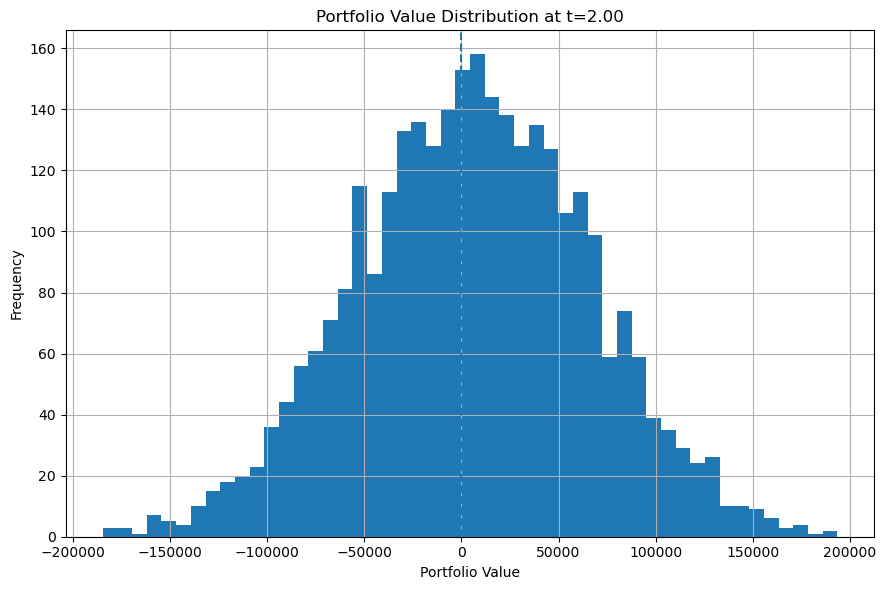

In [19]:
selected_time = 2.0

plot_portfolio_value_distribution(
    exposure_times=exposure_result.exposure_times,
    portfolio_values=exposure_result.portfolio_values,
    selected_time=selected_time,
    number_of_bins=50
)

In [20]:
selected_index = np.where(
    np.isclose(
        exposure_result.exposure_times,
        selected_time
    )
)[0][0]

pd.Series(
    exposure_result.portfolio_values[
        :,
        selected_index
    ]
).describe(
    percentiles=[
        0.05,
        0.50,
        0.95,
        0.99
    ]
)

count      3000.000000
mean       5861.626035
std       60173.255263
min     -184613.516005
5%       -93180.365298
50%        6820.171949
95%      103820.721338
99%      142500.767271
max      193508.410234
dtype: float64

## 13. EE, ENE, EPE, and PFE

Pathwise positive exposure is:

$$
PE_m(t)
=
\max
\left[
V_m(t),
0
\right].
$$

Pathwise negative exposure is:

$$
NE_m(t)
=
\max
\left[
-V_m(t),
0
\right].
$$

Expected exposure is:

$$
EE(t)
=
\mathbb{E}
\left[
\max
\left(
V(t),
0
\right)
\right].
$$

Expected negative exposure is:

$$
ENE(t)
=
\mathbb{E}
\left[
\max
\left(
-V(t),
0
\right)
\right].
$$

Potential future exposure at confidence level \(q\) is:

$$
PFE_q(t)
=
Q_q
\left[
\max
\left(
V(t),
0
\right)
\right].
$$

Expected positive exposure is the time-weighted average:

$$
EPE
=
\frac{1}{T}
\int_0^T EE(t)\,dt.
$$

In [21]:
uncollateralized_metrics = calculate_exposure_metrics(
    times=exposure_result.exposure_times,
    portfolio_values=exposure_result.portfolio_values,
    pfe_confidence_level=0.95
)

uncollateralized_metrics.profile_table()

,time,EE,ENE,PFE
0,0.0,0.000000,279541.222243,0.000000
1,0.5,590.328166,166347.830631,0.000000
2,1.0,8698.542723,66914.550170,60610.929655
3,1.5,17204.239165,41973.703027,89011.419309
4,2.0,27184.565453,21322.939418,103820.721338
5,2.5,45798.168477,7258.260824,128956.189171
6,3.0,73541.606807,3070.077527,174445.828635
7,3.5,104817.176572,3751.594490,248660.418398
8,4.0,137651.682844,7350.372994,340517.683296
9,4.5,171966.669641,13910.848246,441358.748976


{'EPE': 79243.47133987444, 'average_ENE': 38723.09708095307, 'maximum_EE': 207780.28584422995, 'maximum_ENE': 279541.22224271117, 'maximum_PFE': 558279.0699846215, 'PFE_confidence_level': 0.95}


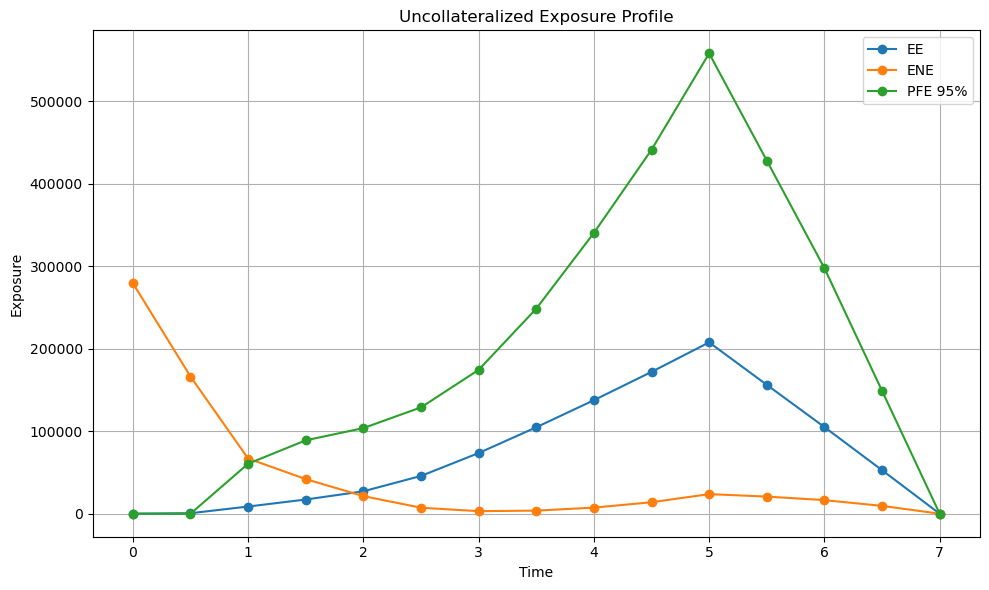

In [22]:
print(
    uncollateralized_metrics.summary()
)

plot_exposure_profile(
    uncollateralized_metrics,
    title="Uncollateralized Exposure Profile"
)

## 14. Introduce a Simplified CSA

The collateral agreement contains:

- counterparty threshold;
- bank threshold;
- minimum transfer amount;
- independent amounts;
- collateral lag.

Residual portfolio value is:

$$
V^{\mathrm{res}}(t)
=
V(t)-C(t).
$$

Non-zero thresholds and collateral lag leave residual counterparty exposure.

In [23]:
csa = CSAParameters(
    counterparty_threshold=250_000.0,
    bank_threshold=250_000.0,
    minimum_transfer_amount=50_000.0,
    counterparty_independent_amount=0.0,
    bank_independent_amount=0.0,
    collateral_lag_steps=1
)

csa.summary()

{'counterparty_threshold': 250000.0,
 'bank_threshold': 250000.0,
 'minimum_transfer_amount': 50000.0,
 'counterparty_independent_amount': 0.0,
 'bank_independent_amount': 0.0,
 'collateral_lag_steps': 1}

In [24]:
collateral_paths = simulate_collateral_paths(
    portfolio_values=exposure_result.portfolio_values,
    csa_parameters=csa
)

collateralized_values = collateralized_portfolio_values(
    portfolio_values=exposure_result.portfolio_values,
    collateral_paths=collateral_paths
)

## 15. Compare Collateralized and Uncollateralized Exposure

Collateral should generally reduce:

- EE;
- PFE;
- EPE;
- CVA;
- funding exposure.

It does not necessarily eliminate exposure because of thresholds, MTA, and collateral lag.

In [25]:
collateralized_metrics = calculate_exposure_metrics(
    times=exposure_result.exposure_times,
    portfolio_values=collateralized_values,
    pfe_confidence_level=0.95
)

compare_exposure_profiles(
    uncollateralized_metrics,
    collateralized_metrics
)

,time,EE_uncollateralized,EE_collateralized,PFE_uncollateralized,PFE_collateralized
0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.5,590.328166,590.328166,0.000000,0.000000
2,1.0,8698.542723,8748.382579,60610.929655,60610.929655
3,1.5,17204.239165,17204.239165,89011.419309,89011.419309
4,2.0,27184.565453,27184.565453,103820.721338,103820.721338
5,2.5,45798.168477,45802.561242,128956.189171,128956.189171
6,3.0,73541.606807,73550.507663,174445.828635,174445.828635
7,3.5,104817.176572,104826.480391,248660.418398,248660.418398
8,4.0,137651.682844,136212.968126,340517.683296,334256.899670
9,4.5,171966.669641,161868.893994,441358.748976,379719.667002


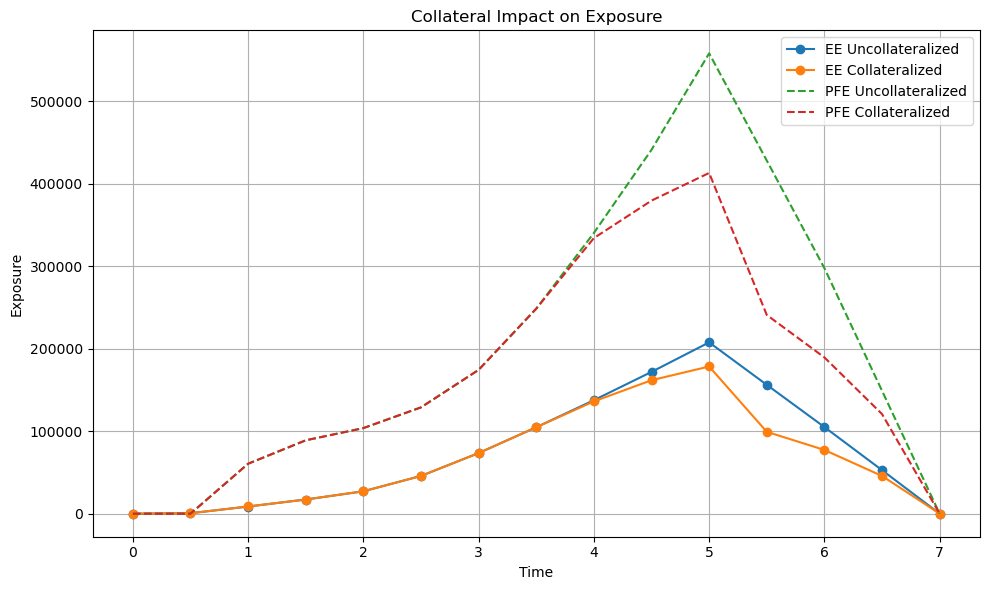

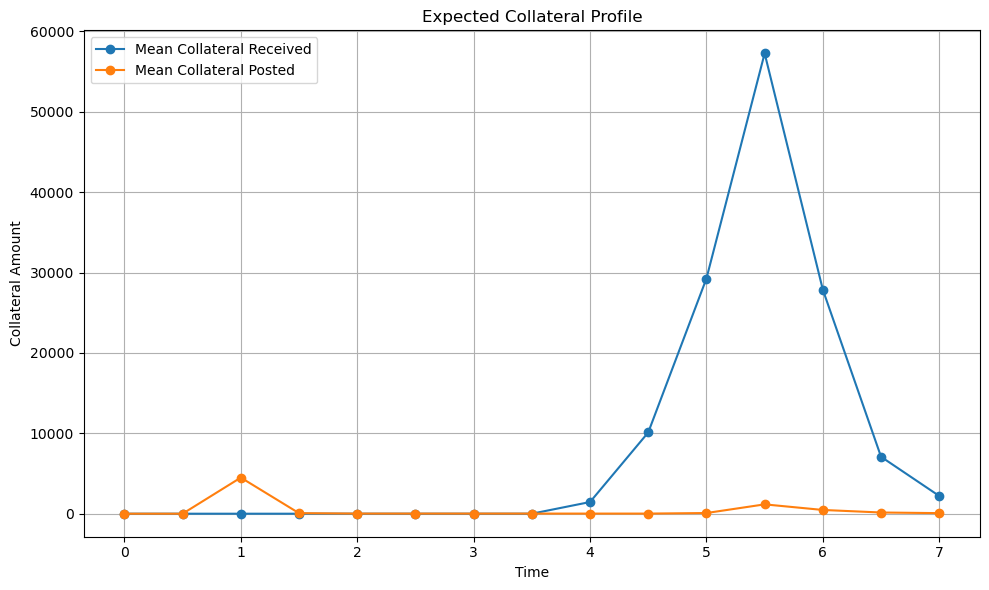

In [26]:
plot_collateral_comparison(
    uncollateralized_metrics,
    collateralized_metrics
)

plot_mean_collateral_profile(
    exposure_times=exposure_result.exposure_times,
    collateral_paths=collateral_paths
)

## 16. Credit Curves and Default Probabilities

With flat hazard rate \(\lambda\), survival probability is:

$$
S(t)
=
\exp
\left[
-\lambda t
\right].
$$

Marginal default probability is approximated by:

$$
\Delta PD_i
=
S(t_{i-1})
-
S(t_i).
$$

Loss given default is:

$$
LGD
=
1-R.
$$

In [27]:
counterparty_credit_curve = CreditCurve(
    hazard_rate=0.020,
    recovery_rate=0.40
)

bank_credit_curve = CreditCurve(
    hazard_rate=0.012,
    recovery_rate=0.40
)

pd.DataFrame(
    {
        "time": exposure_result.exposure_times,
        "counterparty_survival": (
            counterparty_credit_curve
            .survival_probability(
                exposure_result.exposure_times
            )
        ),
        "bank_survival": (
            bank_credit_curve
            .survival_probability(
                exposure_result.exposure_times
            )
        )
    }
)

,time,counterparty_survival,bank_survival
0,0.0,1.000000,1.000000
1,0.5,0.990050,0.994018
2,1.0,0.980199,0.988072
3,1.5,0.970446,0.982161
4,2.0,0.960789,0.976286
5,2.5,0.951229,0.970446
6,3.0,0.941765,0.964640
7,3.5,0.932394,0.958870
8,4.0,0.923116,0.953134
9,4.5,0.913931,0.947432


## 17. Calculate CVA, DVA, and Simplified FVA

The discrete CVA approximation is:

$$
CVA
=
LGD_C
\sum_i
DF(0,t_i)
EE(t_i)
\Delta PD_C(t_i).
$$

DVA is:

$$
DVA
=
LGD_B
\sum_i
DF(0,t_i)
ENE(t_i)
\Delta PD_B(t_i).
$$

The simplified funding adjustments are:

$$
FCA
=
\sum_i
DF(0,t_i)
EE(t_i)
s_B
\Delta t_i,
$$

$$
FBA
=
\sum_i
DF(0,t_i)
ENE(t_i)
s_L
\Delta t_i,
$$

and:

$$
FVA
=
FCA-FBA.
$$

The net adjustment is:

$$
XVA_{\mathrm{net}}
=
-CVA
+
DVA
-
FVA.
$$

In [28]:
uncollateralized_xva = calculate_xva(
    model=model,
    exposure_metrics=uncollateralized_metrics,
    counterparty_credit_curve=counterparty_credit_curve,
    bank_credit_curve=bank_credit_curve,
    borrowing_spread=0.012,
    lending_spread=0.003
)

collateralized_xva = calculate_xva(
    model=model,
    exposure_metrics=collateralized_metrics,
    counterparty_credit_curve=counterparty_credit_curve,
    bank_credit_curve=bank_credit_curve,
    borrowing_spread=0.012,
    lending_spread=0.003
)

pd.DataFrame(
    {
        "uncollateralized": uncollateralized_xva,
        "collateralized": collateralized_xva
    }
)

,uncollateralized,collateralized
CVA,5431.945993,4815.150952
DVA,1354.705239,1340.849826
FCA,5906.514574,5222.178563
FBA,575.194572,569.459129
FVA,5331.320003,4652.719434
net_valuation_adjustment,-9408.560757,-8127.020560


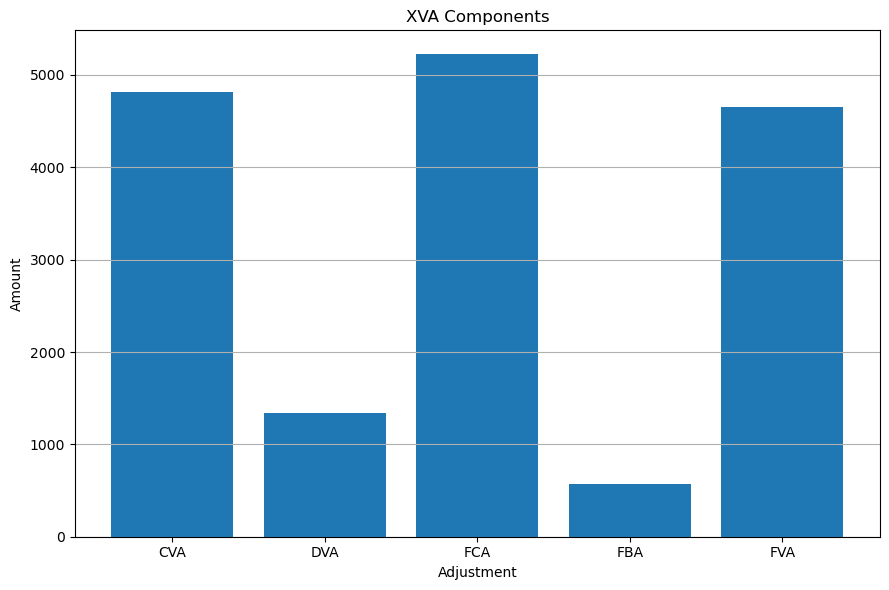

In [29]:
plot_xva_components(
    collateralized_xva
)

## 18. Interpretation, Limitations, and Summary

The full Chapter 15 workflow is:

```text
Gaussian LMM paths
        ↓
future swap valuation
        ↓
netting-set value
        ↓
positive and negative exposure
        ↓
EE, ENE, EPE, and PFE
        ↓
collateral
        ↓
CVA, DVA, and FVA
```

The framework deliberately omits:

- wrong-way risk;
- stochastic hazard rates;
- multi-curve valuation;
- margin period of risk re-simulation;
- initial margin and MVA;
- KVA;
- replacement close-out;
- nested Monte Carlo;
- full regulatory EPE conventions.

The chapter is designed to explain the core architecture used by counterparty-risk and XVA systems without hiding the logic behind a production framework.